
# Assignment 03 — House Price Prediction Vietnam 2024
## Traditional Machine Learning vs. 5-Layer Deep Neural Network

### Bài toán

Ta cần dự đoán **giá nhà** từ các đặc trưng của bất động sản.

\[
X = \text{house characteristics}
\]

\[
y = \text{house price}
\]

Đây là **Regression**, vì output là một giá trị liên tục chứ không phải class.

### Dataset

**House Price Prediction Dataset Vietnam - 2024**

Theo cấu trúc dataset đã sử dụng ở Assignment 02, dữ liệu gồm:

- `Address`
- `Area`
- `Frontage`
- `Access Road`
- `House direction`
- `Balcony direction`
- `Floors`
- `Bedrooms`
- `Bathrooms`
- `Legal status`
- `Furniture state`
- `Price`

Trong notebook này:

- `Price` là target.
- `Address` không được đưa vào baseline model vì là free-text/high-cardinality.
- 10 feature còn lại được dùng làm model input.

### Mục tiêu Assignment 03

Train và so sánh:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. 5-Layer MLP bằng PyTorch

Metrics:

- MAE
- MSE
- RMSE
- R²
- Training Time

Visualization:

- Price distribution
- Area vs Price
- Correlation matrix
- Validation metrics
- Training/Validation curves của DL
- Final ML vs DL comparison
- Actual vs Predicted
- Residual distribution
- Learned representation của Deep Learning



# 0. Environment Setup

Notebook sử dụng **PyTorch** cho phần Deep Learning.

Nếu cell import báo:

```text
ModuleNotFoundError: No module named 'torch'
```

hãy chạy một lần:

```python
%pip install torch
```

sau đó **Restart Kernel** và chạy notebook lại từ đầu.


In [53]:

# Uncomment only if PyTorch is not installed:
# %pip install torch



# 1. Import Libraries


In [54]:

import os
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader



# 2. Reproducibility

Giữ random seed cố định giúp kết quả dễ tái lập hơn.


In [55]:

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

TARGET = "Price"

print("PyTorch version:", torch.__version__)


PyTorch version: 2.14.0+cpu



# 3. Load Dataset

Notebook thử các vị trí phổ biến sau:

1. `vietnam_house_2024.csv`
2. `../data/vietnam_house_2024.csv`
3. `/mnt/data/vietnam_house_2024.csv`

Nếu tên file của bạn khác, chỉ cần sửa `candidate_paths`.


In [56]:

candidate_paths = [
    "housing_dataset.csv",
]

DATA_PATH = None

for path in candidate_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy dataset. "
        "Hãy đặt vietnam_house_2024.csv cùng thư mục notebook "
        "hoặc sửa candidate_paths."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset path :", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())


Dataset path : housing_dataset.csv
Dataset shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90



# 4. Dataset Inspection

Kiểm tra:

- shape;
- column names;
- data types;
- missing values;
- unique values;
- duplicate rows.


In [57]:

print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nInfo:")
df.info()


Columns:
['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']

Shape:
(30229, 12)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
m

In [58]:

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True)
})

display(quality_summary.round(2))

print("Duplicated rows:", df.duplicated().sum())


,dtype,missing_count,missing_pct,unique_values
Address,str,0,0.00,10265
Area,float64,0,0.00,1512
Frontage,float64,11564,38.25,407
Access Road,float64,13297,43.99,140
House direction,str,21239,70.26,8
Balcony direction,str,24983,82.65,8
Floors,float64,3603,11.92,10
Bedrooms,float64,5162,17.08,9
Bathrooms,float64,7074,23.40,9
Legal status,str,4506,14.91,2


Duplicated rows: 0


In [59]:

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,30229,10265,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,30229.0,NaN,NaN,NaN,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,NaN,NaN,NaN,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,NaN,NaN,NaN,7.8538,7.451313,1.0,4.0,6.0,10.0,85.0
House direction,8990,8,Đông - Nam,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balcony direction,5246,8,Đông - Nam,1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,26626.0,NaN,NaN,NaN,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,NaN,NaN,NaN,3.51103,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,NaN,NaN,NaN,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Legal status,25723,2,Have certificate,24774,NaN,NaN,NaN,NaN,NaN,NaN,NaN



# 5. Data Cleaning

## 5.1 Target cleaning

`Price` phải là một số hữu hạn và lớn hơn 0.

## 5.2 Duplicate rows

Loại exact duplicate.

## 5.3 Numerical features

Các cột dự kiến là numerical:

- Area
- Frontage
- Access Road
- Floors
- Bedrooms
- Bathrooms

Các giá trị không chuyển được sang số sẽ trở thành `NaN` và được xử lý bằng imputation sau đó.

## 5.4 Address

`Address` là free-text/high-cardinality nên được loại khỏi baseline representation.


In [60]:

df_clean = df.copy()

# Target -> numeric
df_clean[TARGET] = pd.to_numeric(
    df_clean[TARGET],
    errors="coerce"
)

before = len(df_clean)

df_clean = df_clean[
    df_clean[TARGET].notna()
    & np.isfinite(df_clean[TARGET])
    & (df_clean[TARGET] > 0)
].copy()

print("Removed invalid target rows:", before - len(df_clean))


Removed invalid target rows: 0


In [61]:

before = len(df_clean)

df_clean = (
    df_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Removed duplicated rows:", before - len(df_clean))
print("Shape after duplicate removal:", df_clean.shape)


Removed duplicated rows: 0
Shape after duplicate removal: (30229, 12)


In [62]:

expected_numeric = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms"
]

for col in expected_numeric:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"
        )

available_numeric = [
    col for col in expected_numeric
    if col in df_clean.columns
]

display(
    df_clean[available_numeric + [TARGET]]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
Area,30229.0,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,7.853800,7.451313,1.0,4.0,6.0,10.0,85.0
Floors,26626.0,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,3.511030,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Price,30229.0,5.872078,2.211877,1.0,4.2,5.9,7.5,11.5


In [63]:

invalid_checks = {}

for col in available_numeric:
    invalid_checks[col] = int(
        (df_clean[col] < 0).sum()
    )

if "Area" in df_clean.columns:
    invalid_checks["Area <= 0"] = int(
        (df_clean["Area"] <= 0).sum()
    )

display(
    pd.Series(
        invalid_checks,
        name="invalid_count"
    ).to_frame()
)


,invalid_count
Area,0
Frontage,0
Access Road,0
Floors,0
Bedrooms,0
Bathrooms,0
Area <= 0,0


In [64]:

# Remove impossible non-positive Area.
# Other missing values are kept and handled by the preprocessing pipeline.

if "Area" in df_clean.columns:
    before = len(df_clean)

    df_clean = df_clean[
        df_clean["Area"].isna()
        | (df_clean["Area"] > 0)
    ].copy()

    print(
        "Removed invalid Area rows:",
        before - len(df_clean)
    )

df_clean.reset_index(
    drop=True,
    inplace=True
)

print("Final cleaned shape:", df_clean.shape)


Removed invalid Area rows: 0
Final cleaned shape: (30229, 12)



# 6. Feature / Target Definition

\[
X = \text{house features}
\]

\[
y = Price
\]

`Address` và `Price` được loại khỏi input.


In [65]:

DROP_COLUMNS = [
    col
    for col in ["Address", TARGET]
    if col in df_clean.columns
]

X = df_clean.drop(
    columns=DROP_COLUMNS
)

y = df_clean[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Input columns:")
print(X.columns.tolist())

display(X.head())


X shape: (30229, 10)
y shape: (30229,)
Input columns:
['Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state']


,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state
0,84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN
1,60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN
2,90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN
3,54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full
4,92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full


In [66]:

numerical_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']

Categorical features:
['House direction', 'Balcony direction', 'Legal status', 'Furniture state']



# 7. Data Representation

Traditional ML và Deep Learning không trực tiếp sử dụng raw DataFrame có categorical strings.

Pipeline:

```text
Raw CSV
   ↓
DataFrame
   ↓
Clean Data
   ↓
Numerical: Imputation + StandardScaler
Categorical: Imputation + One-Hot Encoding
   ↓
Numerical Feature Matrix X
   ↓
ML / DL
```

Sau preprocessing:

\[
X \in \mathbb{R}^{N\times d}
\]

trong đó:

- \(N\): số căn nhà;
- \(d\): số numerical dimensions sau scaling + one-hot encoding.


In [67]:

print(
    "Raw feature matrix shape:",
    X.shape
)

print(
    "Target vector shape:",
    y.shape
)

print(
    "Raw input feature count:",
    X.shape[1]
)

print("\nOne raw observation:")
display(X.iloc[[0]])


Raw feature matrix shape: (30229, 10)
Target vector shape: (30229,)
Raw input feature count: 10

One raw observation:


,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state
0,84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN



# 8. Exploratory Data Analysis


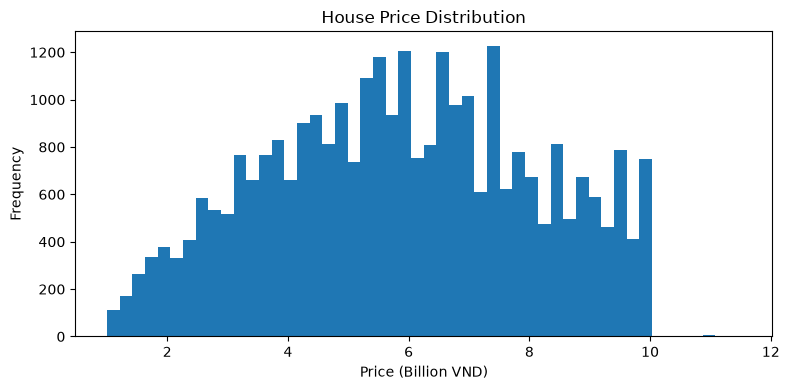

In [68]:

plt.figure(figsize=(8, 4))

plt.hist(
    y,
    bins=50
)

plt.xlabel("Price (Billion VND)")
plt.ylabel("Frequency")
plt.title("House Price Distribution")

plt.tight_layout()
plt.show()


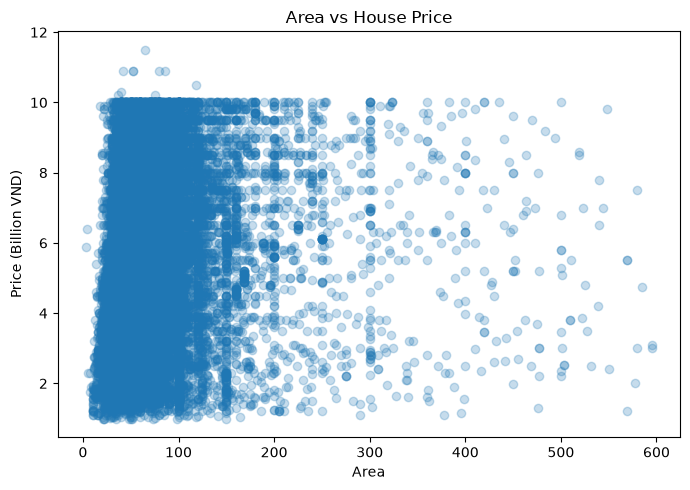

In [69]:

if "Area" in df_clean.columns:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df_clean["Area"],
        df_clean[TARGET],
        alpha=0.25
    )

    plt.xlabel("Area")
    plt.ylabel("Price (Billion VND)")
    plt.title("Area vs House Price")

    plt.tight_layout()
    plt.show()


C:\Users\HDung\AppData\Local\Temp\ipykernel_16140\4267259290.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


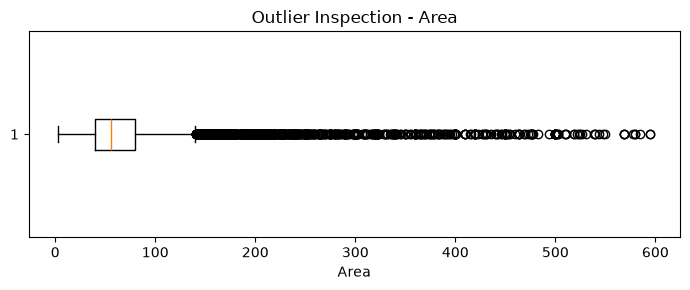

C:\Users\HDung\AppData\Local\Temp\ipykernel_16140\4267259290.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


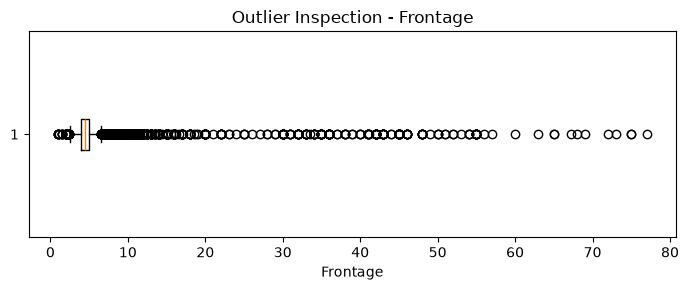

C:\Users\HDung\AppData\Local\Temp\ipykernel_16140\4267259290.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


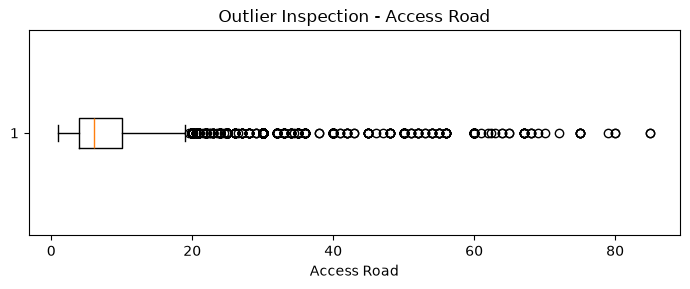

C:\Users\HDung\AppData\Local\Temp\ipykernel_16140\4267259290.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


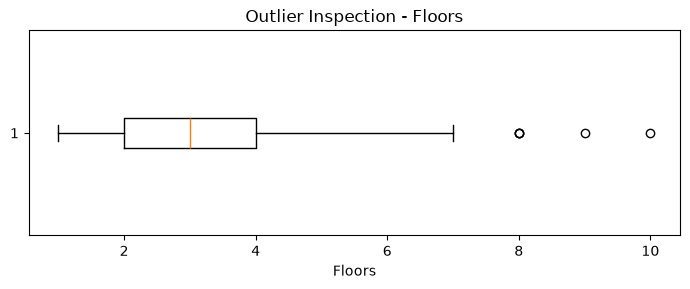

C:\Users\HDung\AppData\Local\Temp\ipykernel_16140\4267259290.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


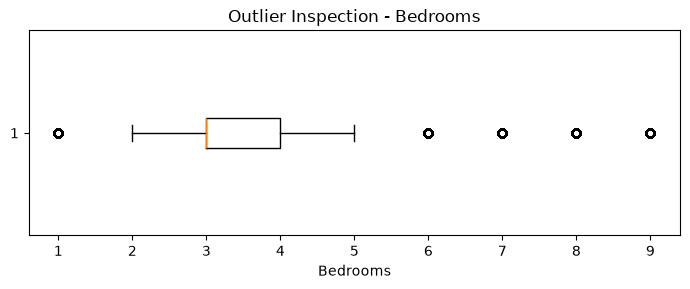

C:\Users\HDung\AppData\Local\Temp\ipykernel_16140\4267259290.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


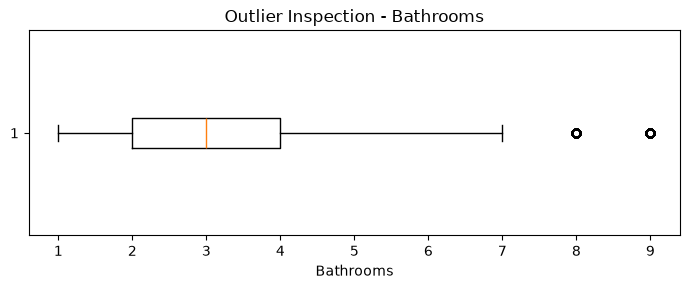

In [70]:

important_numeric = [
    col
    for col in expected_numeric
    if col in df_clean.columns
]

for col in important_numeric:

    plt.figure(figsize=(7, 3))

    plt.boxplot(
        df_clean[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(
        f"Outlier Inspection - {col}"
    )

    plt.tight_layout()
    plt.show()


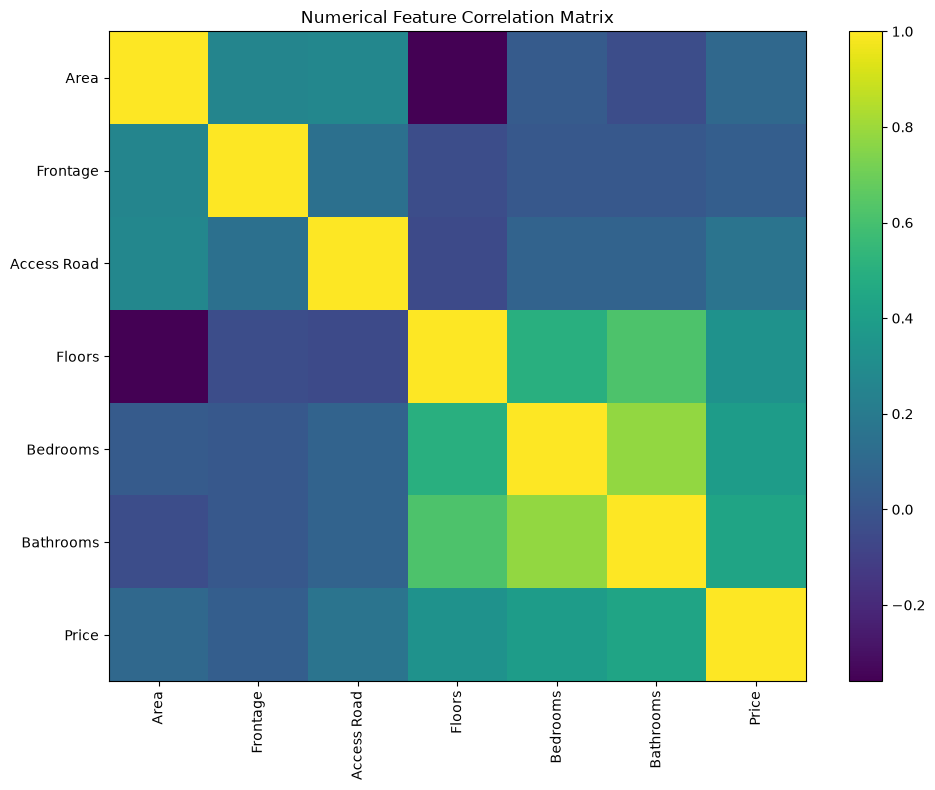

,Correlation with Price
Bathrooms,0.434101
Bedrooms,0.389432
Floors,0.331639
Access Road,0.164280
Area,0.097593
Frontage,0.047469


In [71]:

numeric_df = df_clean.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Numerical Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()

if TARGET in correlation_matrix.columns:
    display(
        correlation_matrix[TARGET]
        .drop(TARGET)
        .sort_values(
            key=abs,
            ascending=False
        )
        .to_frame(
            name="Correlation with Price"
        )
    )



# 9. Train / Validation / Test Split

Ta sử dụng:

- 70% Train
- 15% Validation
- 15% Test

Khác với classification, regression target là continuous nên **không dùng `stratify=y`**.


In [72]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Set": [
        "Train",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],
    "Percentage": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100
    ],
    "Mean Price": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

display(
    split_summary.round(4)
)


,Set,Rows,Percentage,Mean Price
0,Train,21160,69.9990,5.8757
1,Validation,4534,14.9988,5.8602
2,Test,4535,15.0022,5.8670



# 10. Preprocessing

## Numerical pipeline

\[
x'=\frac{x-\mu}{\sigma}
\]

Pipeline:

```text
Missing Numerical
      ↓
Median Imputation
      ↓
StandardScaler
```

## Categorical pipeline

```text
Missing Category
      ↓
Most Frequent Imputation
      ↓
One-Hot Encoding
```

Preprocessor chỉ được `fit` trên training data để tránh data leakage.


In [73]:

def create_one_hot_encoder():
    # Compatible with both newer and older sklearn versions
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


def build_preprocessor(X_reference):

    numerical = (
        X_reference
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical = (
        X_reference
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                create_one_hot_encoder()
            )
        ]
    )

    transformer = ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                numerical
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical
            )
        ]
    )

    return transformer


In [74]:

preprocessor = build_preprocessor(
    X_train
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

processed_feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Raw train shape:",
    X_train.shape
)

print(
    "Processed train shape:",
    X_train_processed.shape
)

print(
    "Processed validation shape:",
    X_val_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

print(
    "Processed feature count:",
    len(processed_feature_names)
)

print(
    "Processed dtype:",
    X_train_processed.dtype
)


Raw train shape: (21160, 10)
Processed train shape: (21160, 26)
Processed validation shape: (4534, 26)
Processed test shape: (4535, 26)
Processed feature count: 26
Processed dtype: float64


In [75]:

sample_raw = X_train.iloc[[0]]

sample_processed = (
    preprocessor
    .transform(sample_raw)
)

sample_processed_df = pd.DataFrame(
    sample_processed,
    columns=processed_feature_names
)

print("Raw representation:")
display(sample_raw)

print("Numerical representation:")
display(sample_processed_df)


Raw representation:


,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state
30205,75.0,5.0,5.5,NaN,NaN,1.0,2.0,2.0,Have certificate,Full


Numerical representation:


,numerical__Area,numerical__Frontage,numerical__Access Road,numerical__Floors,numerical__Bedrooms,numerical__Bathrooms,categorical__House direction_Bắc,categorical__House direction_Nam,categorical__House direction_Tây,categorical__House direction_Tây - Bắc,...,categorical__Balcony direction_Tây,categorical__Balcony direction_Tây - Bắc,categorical__Balcony direction_Tây - Nam,categorical__Balcony direction_Đông,categorical__Balcony direction_Đông - Bắc,categorical__Balcony direction_Đông - Nam,categorical__Legal status_Have certificate,categorical__Legal status_Sale contract,categorical__Furniture state_Basic,categorical__Furniture state_Full
0,0.141052,-0.003974,-0.270927,-1.886174,-1.17792,-1.022481,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0



# 11. Regression Metrics

Vì House Price là regression nên **không dùng Accuracy, Precision, Recall hay F1**.

## MAE

\[
MAE=
\frac{1}{N}
\sum_{i=1}^{N}
|y_i-\hat y_i|
\]

Ý nghĩa: sai lệch tuyệt đối trung bình.

---

## MSE

\[
MSE=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat y_i)^2
\]

Các lỗi lớn bị phạt mạnh hơn vì được bình phương.

---

## RMSE

\[
RMSE=\sqrt{MSE}
\]

RMSE có cùng đơn vị với `Price`.

---

## R²

\[
R^2 =
1-
\frac{\sum_i(y_i-\hat y_i)^2}
{\sum_i(y_i-\bar y)^2}
\]

- \(R^2=1\): hoàn hảo;
- \(R^2=0\): tương đương dự đoán bằng mean;
- \(R^2<0\): tệ hơn baseline mean prediction.


In [76]:

def regression_metrics(
    y_true,
    y_pred
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }



# 12. Traditional ML — 3 Models

Ta sử dụng:

1. **Linear Regression**  
   Baseline tuyến tính.

2. **Random Forest Regressor**  
   Ensemble của nhiều Decision Trees.

3. **Gradient Boosting Regressor**  
   Các weak learners được xây tuần tự để sửa lỗi của model trước.


In [77]:

ml_models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
}


In [78]:

ml_validation_results = []
trained_ml_models = {}

for name, model in ml_models.items():

    print(
        f"Training {name}..."
    )

    start = time.perf_counter()

    model.fit(
        X_train_processed,
        y_train
    )

    training_time = (
        time.perf_counter()
        - start
    )

    y_val_pred = model.predict(
        X_val_processed
    )

    metrics = regression_metrics(
        y_val,
        y_val_pred
    )

    ml_validation_results.append({
        "Model": name,
        **metrics,
        "Training Time (s)": training_time
    })

    trained_ml_models[name] = model


Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...


In [79]:

ml_validation_df = (
    pd.DataFrame(
        ml_validation_results
    )
    .sort_values(
        by=["RMSE", "R2"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    ml_validation_df.round(4)
)


,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Gradient Boosting,1.5038,3.4567,1.8592,0.3032,5.4335
1,Random Forest,1.4801,3.6097,1.8999,0.2723,7.0903
2,Linear Regression,1.6378,3.9786,1.9946,0.1980,0.0616



## 12.1 Visualization — ML Validation Comparison


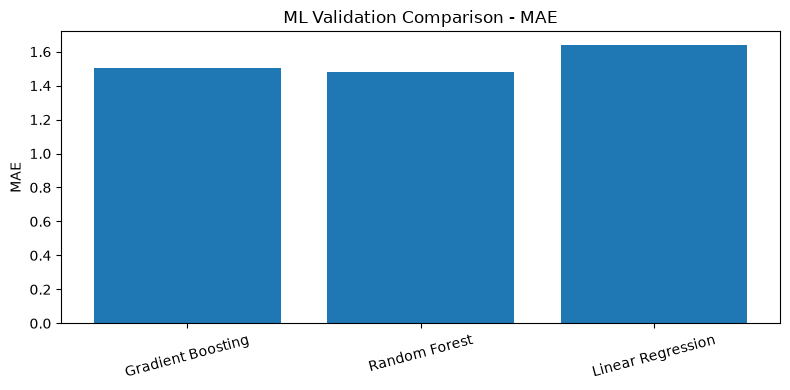

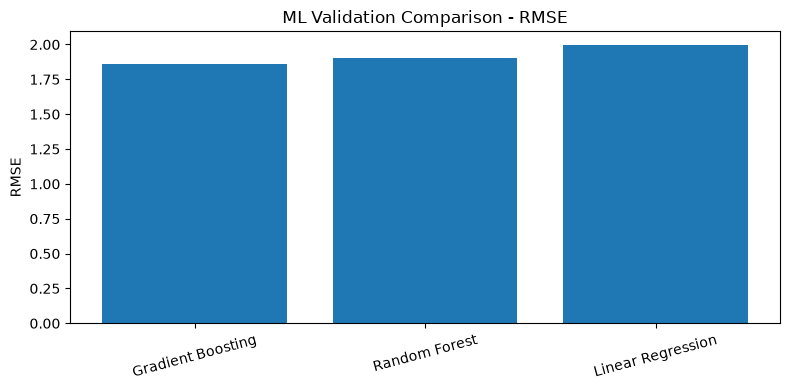

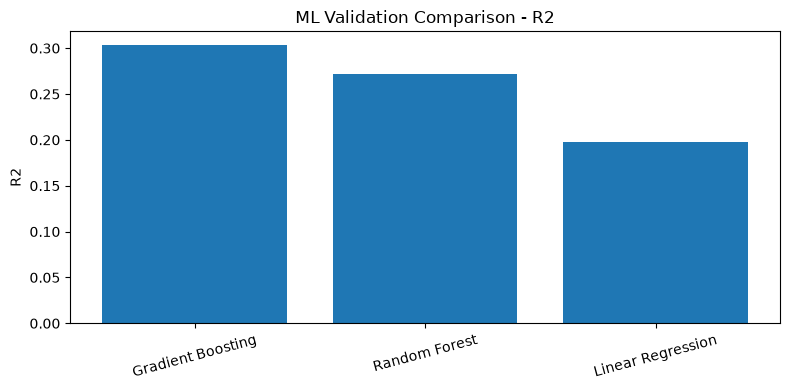

In [80]:

for metric in [
    "MAE",
    "RMSE",
    "R2"
]:
    plt.figure(figsize=(8, 4))

    plt.bar(
        ml_validation_df["Model"],
        ml_validation_df[metric]
    )

    plt.ylabel(metric)
    plt.title(
        f"ML Validation Comparison - {metric}"
    )

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



# 13. Deep Learning Theory — 5-Layer MLP

Assignment 03 nhấn mạnh rằng Deep Learning học **representation** qua nhiều phép biến đổi liên tiếp.

Với input đã preprocessing:

\[
X\in\mathbb{R}^{N\times d}
\]

Ta xây mạng:

\[
d \rightarrow 128 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow 1
\]

Đây là **5 trainable Linear layers**.

---

## 13.1 Linear Transformation

Một layer tính:

\[
Z = HW+b
\]

---

## 13.2 ReLU

\[
ReLU(z)=\max(0,z)
\]

ReLU tạo **nonlinearity**. Nếu chỉ xếp nhiều linear layers mà không có activation phi tuyến, toàn bộ network vẫn tương đương một linear transformation.

---

## 13.3 Forward Propagation của mạng 5 lớp

### Layer 1

\[
Z_1=XW_1+b_1
\]

\[
H_1=ReLU(Z_1)
\]

### Layer 2

\[
Z_2=H_1W_2+b_2
\]

\[
H_2=ReLU(Z_2)
\]

### Layer 3

\[
Z_3=H_2W_3+b_3
\]

\[
H_3=ReLU(Z_3)
\]

### Layer 4

\[
Z_4=H_3W_4+b_4
\]

\[
H_4=ReLU(Z_4)
\]

### Layer 5 — Regression Output

\[
\hat y=H_4W_5+b_5
\]

**Không dùng Sigmoid ở output**, vì house price là continuous value.

Toàn bộ network:

\[
X\rightarrow H_1\rightarrow H_2\rightarrow H_3
\rightarrow H_4\rightarrow \hat y
\]

Các \(H_1,H_2,H_3,H_4\) là các **learned representations**.



# 14. Deep Learning Loss

Ta dùng Mean Squared Error:

\[
L=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat y_i)^2
\]

Trong PyTorch:

```python
criterion = nn.MSELoss()
```

Loss trả lời:

> Với parameters hiện tại, prediction đang sai bao nhiêu?

Mục tiêu training:

\[
\theta^*
=
\arg\min_\theta L(\theta)
\]



# 15. Backpropagation and Gradient Descent

Backpropagation tính gradient:

\[
\nabla_\theta L
\]

Chain rule truyền ảnh hưởng của loss ngược qua các layer.

Training cycle:

```text
Input Batch
    ↓
Forward
    ↓
Loss
    ↓
Backward
    ↓
Optimizer Step
```

Gradient descent:

\[
\theta_{t+1}
=
\theta_t
-
\eta\nabla_\theta L
\]

Trong đó:

- \(\theta\): weights và biases;
- \(\eta\): learning rate;
- \(\nabla_\theta L\): gradient của loss.



# 16. PyTorch Tensor + DataLoader


In [81]:

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

print(
    "X_train_tensor:",
    X_train_tensor.shape
)

print(
    "y_train_tensor:",
    y_train_tensor.shape
)


X_train_tensor: torch.Size([21160, 26])
y_train_tensor: torch.Size([21160, 1])


In [82]:

BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

X_batch, y_batch = next(
    iter(train_loader)
)

print(
    "One X batch:",
    X_batch.shape
)

print(
    "One y batch:",
    y_batch.shape
)


One X batch: torch.Size([64, 26])
One y batch: torch.Size([64, 1])



# 17. Define 5-Layer MLP


In [83]:

class HousePriceMLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        # Layer 1
        self.fc1 = nn.Linear(
            input_dim,
            128
        )

        # Layer 2
        self.fc2 = nn.Linear(
            128,
            64
        )

        # Layer 3
        self.fc3 = nn.Linear(
            64,
            32
        )

        # Layer 4
        self.fc4 = nn.Linear(
            32,
            16
        )

        # Layer 5 - Regression output
        self.fc5 = nn.Linear(
            16,
            1
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        h1 = self.relu(
            self.fc1(x)
        )

        h2 = self.relu(
            self.fc2(h1)
        )

        h3 = self.relu(
            self.fc3(h2)
        )

        h4 = self.relu(
            self.fc4(h3)
        )

        y_hat = self.fc5(h4)

        return y_hat



## 17.1 Tensor Shapes

Nếu batch size là \(B\):

\[
B\times d
\rightarrow
B\times128
\rightarrow
B\times64
\rightarrow
B\times32
\rightarrow
B\times16
\rightarrow
B\times1
\]

Trong đó \(d\) được xác định tự động sau preprocessing.


In [84]:

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

INPUT_DIM = (
    X_train_processed.shape[1]
)

dl_model = HousePriceMLP(
    input_dim=INPUT_DIM
).to(device)

print("Device   :", device)
print("Input dim:", INPUT_DIM)
print(dl_model)


Device   : cpu
Input dim: 26
HousePriceMLP(
  (fc1): Linear(in_features=26, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=16, bias=True)
  (fc5): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)



# 18. Number of Trainable Parameters

Với một Linear layer:

\[
\text{parameters}
=
input\_dim\times output\_dim
+
output\_dim
\]

Phần cuối là bias.

Notebook tính tổng parameter tự động vì \(d\) phụ thuộc số category sau One-Hot Encoding.


In [85]:

total_params = sum(
    p.numel()
    for p in dl_model.parameters()
    if p.requires_grad
)

print(
    "Total trainable parameters:",
    total_params
)

for name, parameter in (
    dl_model.named_parameters()
):
    print(
        f"{name:12s} | "
        f"shape={tuple(parameter.shape)} | "
        f"params={parameter.numel()}"
    )


Total trainable parameters: 14337
fc1.weight   | shape=(128, 26) | params=3328
fc1.bias     | shape=(128,) | params=128
fc2.weight   | shape=(64, 128) | params=8192
fc2.bias     | shape=(64,) | params=64
fc3.weight   | shape=(32, 64) | params=2048
fc3.bias     | shape=(32,) | params=32
fc4.weight   | shape=(16, 32) | params=512
fc4.bias     | shape=(16,) | params=16
fc5.weight   | shape=(1, 16) | params=16
fc5.bias     | shape=(1,) | params=1



# 19. Loss + Optimizer

- Loss: `MSELoss`
- Optimizer: Adam
- Learning rate: `0.001`


In [86]:

LEARNING_RATE = 0.001
NUM_EPOCHS = 200
PATIENCE = 25

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    dl_model.parameters(),
    lr=LEARNING_RATE
)

print("Loss         :", criterion)
print("Optimizer    :", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)
print("Epochs       :", NUM_EPOCHS)
print("Batch size   :", BATCH_SIZE)
print("Patience     :", PATIENCE)


Loss         : MSELoss()
Optimizer    : Adam
Learning rate: 0.001
Epochs       : 200
Batch size   : 64
Patience     : 25



# 20. Evaluation Function for DL

Trong validation/test:

```python
model.eval()

with torch.no_grad():
    predictions = model(X)
```

Không cần gradient vì không cập nhật parameters.


In [87]:

def evaluate_regression_loader(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    predictions = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += (
                loss.item()
                * X_batch.size(0)
            )

            predictions.extend(
                outputs
                .cpu()
                .numpy()
                .ravel()
            )

            targets.extend(
                y_batch
                .cpu()
                .numpy()
                .ravel()
            )

    predictions = np.array(
        predictions
    )

    targets = np.array(
        targets
    )

    avg_loss = (
        total_loss
        / len(loader.dataset)
    )

    metrics = regression_metrics(
        targets,
        predictions
    )

    return {
        "loss": avg_loss,
        "predictions": predictions,
        "targets": targets,
        **metrics
    }



# 21. Training Loop

Mỗi mini-batch:

1. `optimizer.zero_grad()` — reset old gradients
2. `outputs = model(X_batch)` — Forward
3. `loss = criterion(outputs, y_batch)` — Loss
4. `loss.backward()` — Backpropagation
5. `optimizer.step()` — Update parameters

Model tốt nhất được lưu theo **validation RMSE**.


In [88]:

train_losses = []
val_losses = []

train_rmse_history = []
val_rmse_history = []

best_val_rmse = float("inf")
best_model_state = None
best_epoch = None

epochs_without_improvement = 0

dl_start_time = time.perf_counter()

for epoch in range(NUM_EPOCHS):

    # ==========================
    # TRAIN
    # ==========================

    dl_model.train()

    running_loss = 0.0
    train_predictions = []
    train_targets = []

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Reset gradients
        optimizer.zero_grad()

        # 2. Forward
        outputs = dl_model(
            X_batch
        )

        # 3. Loss
        loss = criterion(
            outputs,
            y_batch
        )

        # 4. Backward
        loss.backward()

        # 5. Update
        optimizer.step()

        running_loss += (
            loss.item()
            * X_batch.size(0)
        )

        train_predictions.extend(
            outputs
            .detach()
            .cpu()
            .numpy()
            .ravel()
        )

        train_targets.extend(
            y_batch
            .detach()
            .cpu()
            .numpy()
            .ravel()
        )

    train_loss = (
        running_loss
        / len(train_loader.dataset)
    )

    train_metrics = regression_metrics(
        np.array(train_targets),
        np.array(train_predictions)
    )

    # ==========================
    # VALIDATION
    # ==========================

    val_result = evaluate_regression_loader(
        dl_model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_result["loss"]
    )

    train_rmse_history.append(
        train_metrics["RMSE"]
    )

    val_rmse_history.append(
        val_result["RMSE"]
    )

    # Best model by validation RMSE
    if (
        val_result["RMSE"]
        < best_val_rmse
    ):
        best_val_rmse = (
            val_result["RMSE"]
        )

        best_epoch = epoch + 1

        best_model_state = (
            copy.deepcopy(
                dl_model.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):
        print(
            f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_result['loss']:.4f} | "
            f"Train RMSE: {train_metrics['RMSE']:.4f} | "
            f"Val RMSE: {val_result['RMSE']:.4f}"
        )

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print(
            "\nEarly stopping at epoch",
            epoch + 1
        )
        break

dl_training_time = (
    time.perf_counter()
    - dl_start_time
)

dl_model.load_state_dict(
    best_model_state
)

print("\nTraining completed.")
print("Best epoch       :", best_epoch)
print("Best val RMSE    :", round(best_val_rmse, 4))
print(
    "DL training time :",
    round(dl_training_time, 4),
    "seconds"
)


Epoch   1/200 | Train Loss: 7.6034 | Val Loss: 3.8669 | Train RMSE: 2.7574 | Val RMSE: 1.9664
Epoch  10/200 | Train Loss: 3.3489 | Val Loss: 3.6370 | Train RMSE: 1.8300 | Val RMSE: 1.9071
Epoch  20/200 | Train Loss: 3.2793 | Val Loss: 3.5513 | Train RMSE: 1.8109 | Val RMSE: 1.8845
Epoch  30/200 | Train Loss: 3.2377 | Val Loss: 3.5413 | Train RMSE: 1.7994 | Val RMSE: 1.8818
Epoch  40/200 | Train Loss: 3.1876 | Val Loss: 3.5205 | Train RMSE: 1.7854 | Val RMSE: 1.8763
Epoch  50/200 | Train Loss: 3.1505 | Val Loss: 3.7934 | Train RMSE: 1.7750 | Val RMSE: 1.9477
Epoch  60/200 | Train Loss: 3.1079 | Val Loss: 3.6308 | Train RMSE: 1.7629 | Val RMSE: 1.9055

Early stopping at epoch 66

Training completed.
Best epoch       : 41
Best val RMSE    : 1.8704
DL training time : 133.771 seconds



# 22. Training / Validation Curves

## Good fit

Training và validation cùng cải thiện.

## Overfitting

Training tiếp tục tốt hơn nhưng validation bắt đầu xấu đi.

## Underfitting

Cả training và validation đều còn error cao.


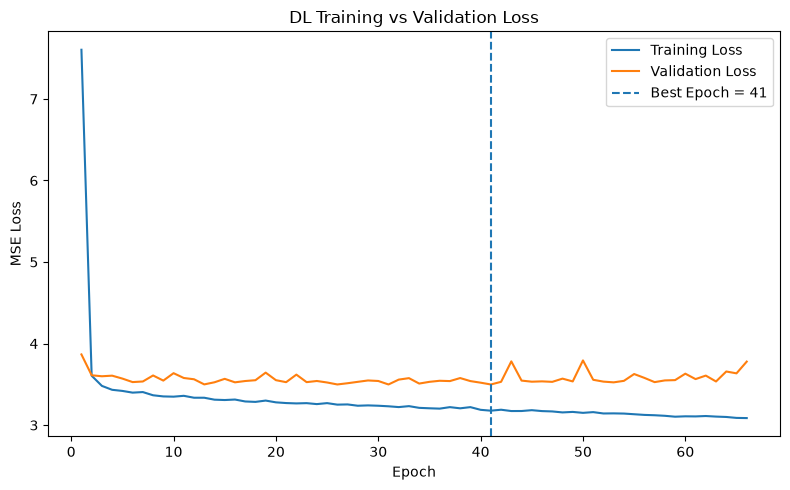

In [89]:

epochs_ran = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "DL Training vs Validation Loss"
)
plt.legend()

plt.tight_layout()
plt.show()


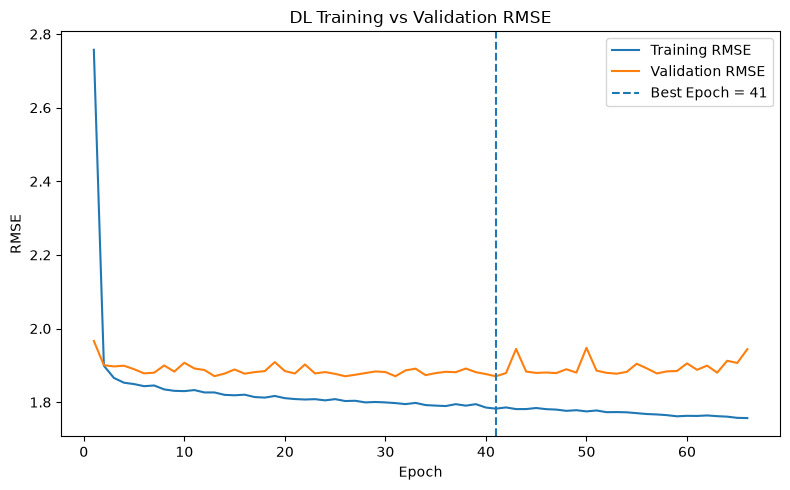

In [90]:

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    train_rmse_history,
    label="Training RMSE"
)

plt.plot(
    epochs_ran,
    val_rmse_history,
    label="Validation RMSE"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title(
    "DL Training vs Validation RMSE"
)
plt.legend()

plt.tight_layout()
plt.show()



# 23. Validation Comparison — 3 ML + DL


In [91]:

dl_val_result = evaluate_regression_loader(
    dl_model,
    val_loader,
    criterion,
    device
)

dl_validation_row = {
    "Model": "5-Layer MLP",
    "MAE": dl_val_result["MAE"],
    "MSE": dl_val_result["MSE"],
    "RMSE": dl_val_result["RMSE"],
    "R2": dl_val_result["R2"],
    "Training Time (s)": dl_training_time
}

validation_comparison = pd.concat(
    [
        ml_validation_df,
        pd.DataFrame(
            [dl_validation_row]
        )
    ],
    ignore_index=True
)

validation_comparison = (
    validation_comparison
    .sort_values(
        by=["RMSE", "R2"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    validation_comparison.round(4)
)


,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Gradient Boosting,1.5038,3.4567,1.8592,0.3032,5.4335
1,5-Layer MLP,1.5100,3.4985,1.8704,0.2948,133.7710
2,Random Forest,1.4801,3.6097,1.8999,0.2723,7.0903
3,Linear Regression,1.6378,3.9786,1.9946,0.1980,0.0616


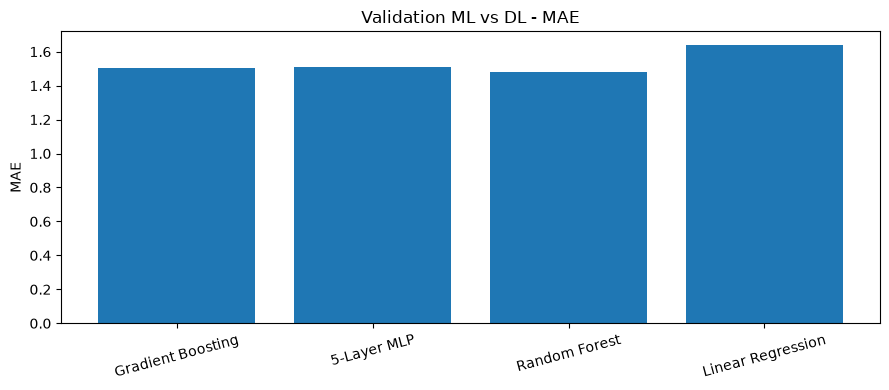

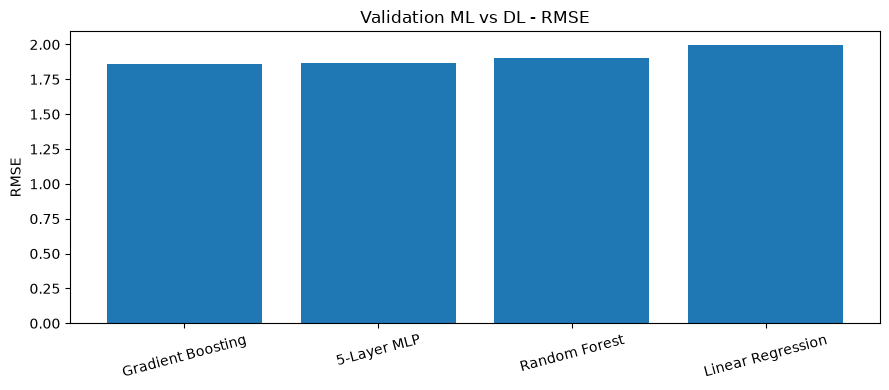

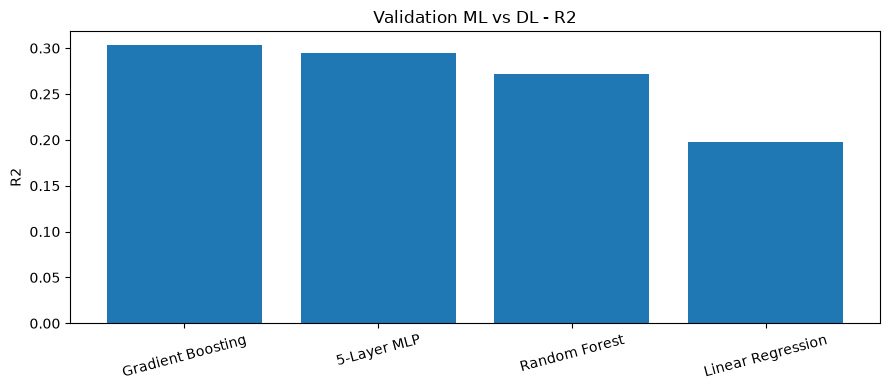

In [92]:

for metric in [
    "MAE",
    "RMSE",
    "R2"
]:

    plt.figure(figsize=(9, 4))

    plt.bar(
        validation_comparison["Model"],
        validation_comparison[metric]
    )

    plt.ylabel(metric)
    plt.title(
        f"Validation ML vs DL - {metric}"
    )

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



# 24. Final Retraining on Train + Validation

Sau khi:

- ML configurations đã cố định;
- DL best epoch đã được chọn;

ta ghép **Train + Validation**, fit lại preprocessor và train lại cả 4 model.

Sau đó Test set mới được sử dụng để đánh giá cuối cùng.


In [93]:

X_train_val = pd.concat(
    [X_train, X_val],
    axis=0
)

y_train_val = pd.concat(
    [y_train, y_val],
    axis=0
)

final_preprocessor = build_preprocessor(
    X_train_val
)

X_train_val_processed = (
    final_preprocessor
    .fit_transform(
        X_train_val
    )
)

X_test_final_processed = (
    final_preprocessor
    .transform(
        X_test
    )
)

final_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

print(
    "Train + Val raw:",
    X_train_val.shape
)

print(
    "Train + Val processed:",
    X_train_val_processed.shape
)

print(
    "Test processed:",
    X_test_final_processed.shape
)


Train + Val raw: (25694, 10)
Train + Val processed: (25694, 26)
Test processed: (4535, 26)



## 24.1 Refit 3 ML Models


In [94]:

final_ml_models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
}

final_test_results = []
final_models = {}

for name, model in (
    final_ml_models.items()
):

    start = time.perf_counter()

    model.fit(
        X_train_val_processed,
        y_train_val
    )

    train_time = (
        time.perf_counter()
        - start
    )

    pred = model.predict(
        X_test_final_processed
    )

    metrics = regression_metrics(
        y_test,
        pred
    )

    final_test_results.append({
        "Model": name,
        **metrics,
        "Training Time (s)": train_time
    })

    final_models[name] = {
        "model": model,
        "prediction": pred
    }



## 24.2 Retrain Final 5-Layer MLP

Mạng được train trên `Train + Validation` trong số epoch đã chọn ở bước trước.


In [95]:

X_train_val_tensor = torch.tensor(
    X_train_val_processed,
    dtype=torch.float32
)

y_train_val_tensor = torch.tensor(
    y_train_val
    .to_numpy()
    .reshape(-1, 1),
    dtype=torch.float32
)

X_test_final_tensor = torch.tensor(
    X_test_final_processed,
    dtype=torch.float32
)

y_test_final_tensor = torch.tensor(
    y_test
    .to_numpy()
    .reshape(-1, 1),
    dtype=torch.float32
)

final_train_dataset = TensorDataset(
    X_train_val_tensor,
    y_train_val_tensor
)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

final_test_dataset = TensorDataset(
    X_test_final_tensor,
    y_test_final_tensor
)

final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [96]:

# Re-seed before final training
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

FINAL_INPUT_DIM = (
    X_train_val_processed.shape[1]
)

final_dl_model = HousePriceMLP(
    FINAL_INPUT_DIM
).to(device)

final_criterion = nn.MSELoss()

final_optimizer = torch.optim.Adam(
    final_dl_model.parameters(),
    lr=LEARNING_RATE
)

final_dl_start = time.perf_counter()

for epoch in range(best_epoch):

    final_dl_model.train()

    for X_batch, y_batch in (
        final_train_loader
    ):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        final_optimizer.zero_grad()

        outputs = final_dl_model(
            X_batch
        )

        loss = final_criterion(
            outputs,
            y_batch
        )

        loss.backward()

        final_optimizer.step()

final_dl_training_time = (
    time.perf_counter()
    - final_dl_start
)

final_dl_test = (
    evaluate_regression_loader(
        final_dl_model,
        final_test_loader,
        final_criterion,
        device
    )
)

final_test_results.append({
    "Model": "5-Layer MLP",
    "MAE": final_dl_test["MAE"],
    "MSE": final_dl_test["MSE"],
    "RMSE": final_dl_test["RMSE"],
    "R2": final_dl_test["R2"],
    "Training Time (s)": final_dl_training_time
})

final_models["5-Layer MLP"] = {
    "model": final_dl_model,
    "prediction": final_dl_test[
        "predictions"
    ]
}



# 25. Final Test Metrics — ML vs DL


In [97]:

final_results_df = (
    pd.DataFrame(
        final_test_results
    )
    .sort_values(
        by=["RMSE", "R2"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    final_results_df.round(4)
)


,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Gradient Boosting,1.4516,3.2641,1.8067,0.3181,5.6517
1,5-Layer MLP,1.4652,3.3734,1.8367,0.2953,92.2532
2,Random Forest,1.4293,3.4486,1.8570,0.2796,7.7531
3,Linear Regression,1.5894,3.8169,1.9537,0.2026,0.0476



## Cách đọc bảng

### MAE
Càng thấp càng tốt.

Ví dụ:

```text
MAE = 1.4
```

nghĩa là prediction lệch tuyệt đối trung bình khoảng **1.4 tỷ VND** nếu target đang dùng đơn vị tỷ VND.

### RMSE
Càng thấp càng tốt. RMSE nhạy với các prediction sai rất lớn.

### R²
Càng cao càng tốt.

### Training Time
Dùng để xem improvement về predictive performance có xứng đáng với computational cost hay không.



# 26. Final Metrics Visualization


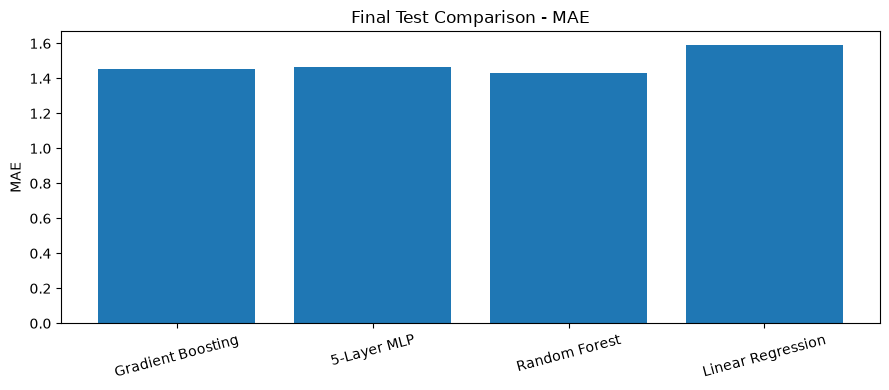

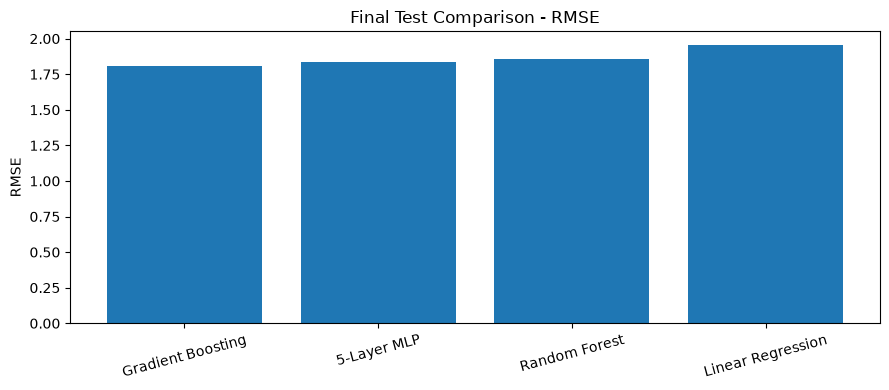

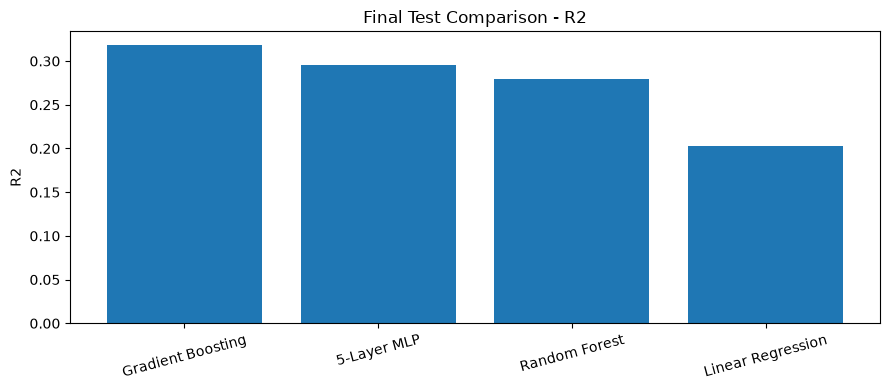

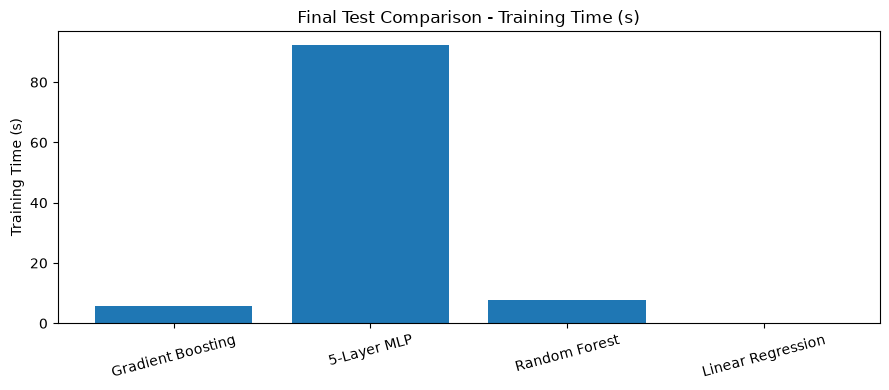

In [98]:

for metric in [
    "MAE",
    "RMSE",
    "R2",
    "Training Time (s)"
]:

    plt.figure(figsize=(9, 4))

    plt.bar(
        final_results_df["Model"],
        final_results_df[metric]
    )

    plt.ylabel(metric)

    plt.title(
        f"Final Test Comparison - {metric}"
    )

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



# 27. Actual vs Predicted

Đường nét đứt biểu diễn prediction lý tưởng:

\[
y=\hat y
\]

Điểm càng gần đường này thì prediction càng chính xác.


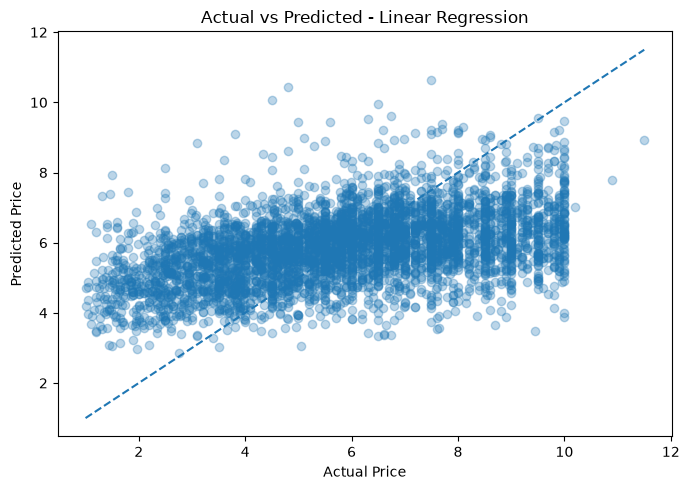

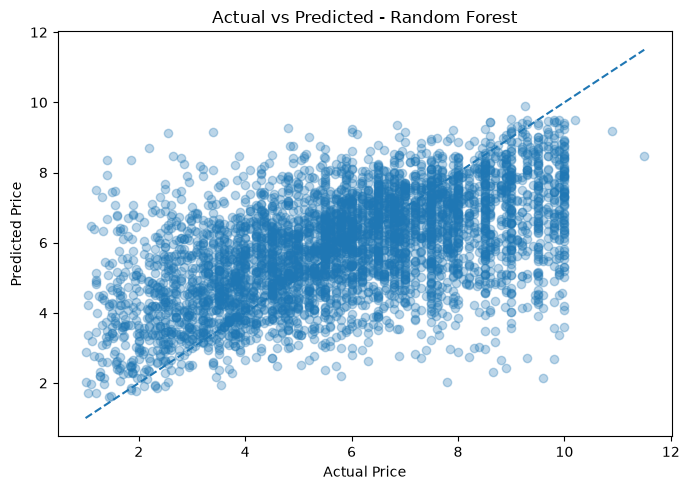

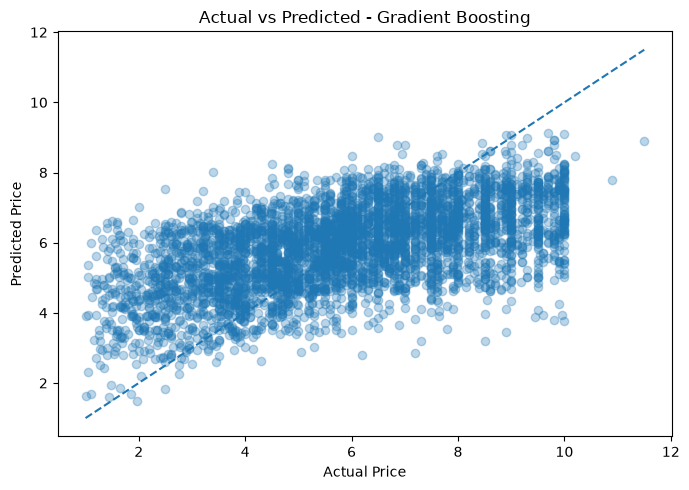

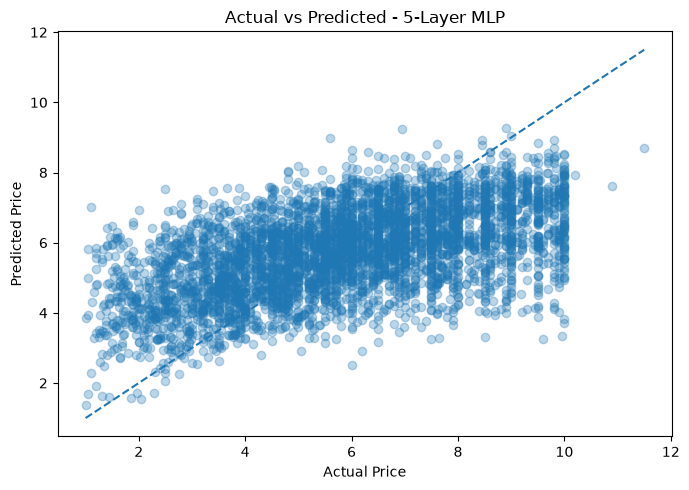

In [99]:

for model_name, data in (
    final_models.items()
):

    y_pred = data["prediction"]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.3
    )

    min_value = min(
        y_test.min(),
        np.min(y_pred)
    )

    max_value = max(
        y_test.max(),
        np.max(y_pred)
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")

    plt.title(
        f"Actual vs Predicted - {model_name}"
    )

    plt.tight_layout()
    plt.show()



# 28. Residual Analysis

Residual:

\[
e_i=y_i-\hat y_i
\]

- Residual gần 0 → prediction tốt.
- Residual dương → model dự đoán thấp hơn actual.
- Residual âm → model dự đoán cao hơn actual.
- Distribution lệch mạnh có thể cho thấy systematic bias.


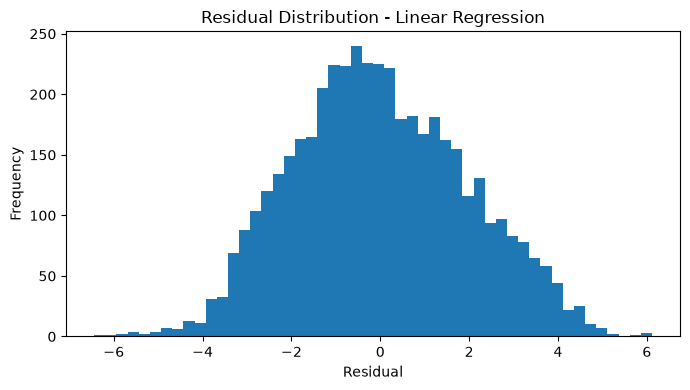

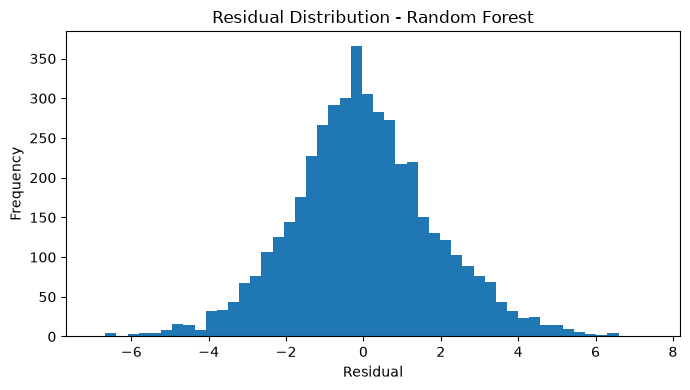

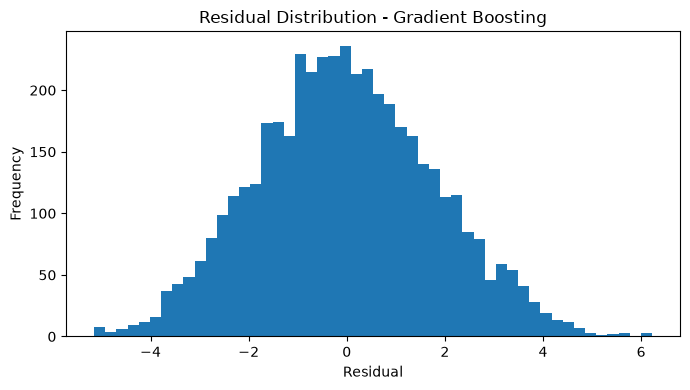

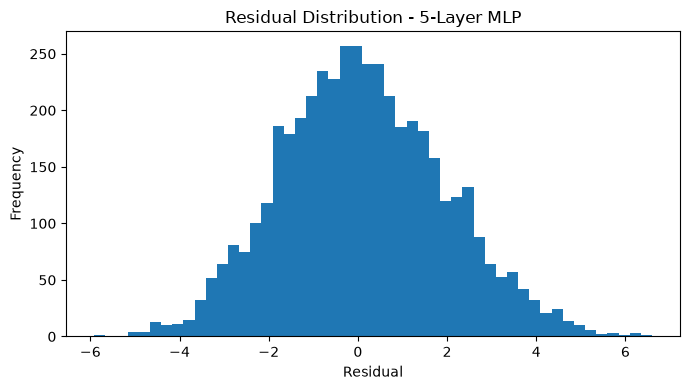

In [100]:

for model_name, data in (
    final_models.items()
):

    y_pred = data["prediction"]

    residual = (
        y_test.to_numpy()
        - y_pred
    )

    plt.figure(figsize=(7, 4))

    plt.hist(
        residual,
        bins=50
    )

    plt.xlabel("Residual")
    plt.ylabel("Frequency")

    plt.title(
        f"Residual Distribution - {model_name}"
    )

    plt.tight_layout()
    plt.show()



# 29. Tree-Based Feature Importance

Random Forest và Gradient Boosting cung cấp `feature_importances_`.

Feature importance giúp xem model tree-based dựa nhiều vào dimension nào sau preprocessing.

> Feature importance không đồng nghĩa với quan hệ nhân quả.


Top features - Random Forest


,Feature,Importance
0,numerical__Area,0.318684
5,numerical__Bathrooms,0.174403
1,numerical__Frontage,0.119555
2,numerical__Access Road,0.110975
3,numerical__Floors,0.097420
4,numerical__Bedrooms,0.061690
13,categorical__House direction_Đông - Nam,0.014948
24,categorical__Furniture state_Basic,0.013780
25,categorical__Furniture state_Full,0.013569
21,categorical__Balcony direction_Đông - Nam,0.009222


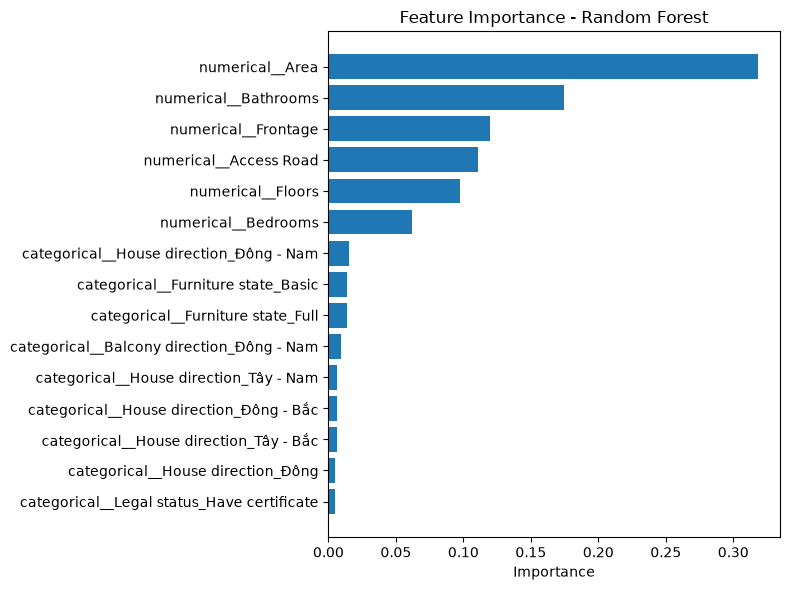

Top features - Gradient Boosting


,Feature,Importance
5,numerical__Bathrooms,0.353773
0,numerical__Area,0.277857
3,numerical__Floors,0.170798
2,numerical__Access Road,0.075428
4,numerical__Bedrooms,0.058300
1,numerical__Frontage,0.024928
13,categorical__House direction_Đông - Nam,0.014754
24,categorical__Furniture state_Basic,0.009560
25,categorical__Furniture state_Full,0.005807
22,categorical__Legal status_Have certificate,0.005196


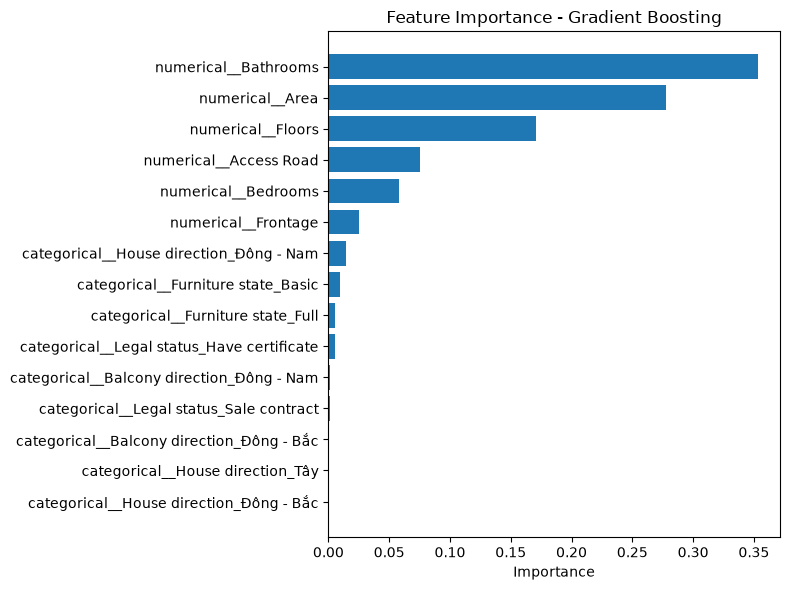

In [101]:

for model_name in [
    "Random Forest",
    "Gradient Boosting"
]:

    model = final_models[
        model_name
    ]["model"]

    if hasattr(
        model,
        "feature_importances_"
    ):
        importance_df = pd.DataFrame({
            "Feature": final_feature_names,
            "Importance":
                model.feature_importances_
        }).sort_values(
            "Importance",
            ascending=False
        )

        print(
            f"Top features - {model_name}"
        )

        display(
            importance_df.head(15)
        )

        top = importance_df.head(15)

        plt.figure(figsize=(8, 6))

        plt.barh(
            top["Feature"],
            top["Importance"]
        )

        plt.gca().invert_yaxis()
        plt.xlabel("Importance")

        plt.title(
            f"Feature Importance - {model_name}"
        )

        plt.tight_layout()
        plt.show()



# 30. Inspect Learned Representation

Một điểm khác biệt quan trọng của Deep Learning:

Traditional ML:

```text
Prepared Numerical Features
        ↓
Algorithm
        ↓
Prediction
```

Deep Learning:

```text
Prepared Numerical Features
        ↓
H1
        ↓
H2
        ↓
H3
        ↓
H4
        ↓
Prediction
```

Ta lấy \(H_4\), tức representation ngay trước output layer.

Sau đó dùng PCA chỉ để visualization xuống 2 chiều.

Nếu learned space thể hiện gradient giá rõ hơn, đó là một bằng chứng trực quan rằng network đã biến đổi representation ban đầu.


In [102]:

def extract_h4(
    model,
    X_tensor,
    device
):

    model.eval()

    with torch.no_grad():

        x = X_tensor.to(device)

        h1 = model.relu(
            model.fc1(x)
        )

        h2 = model.relu(
            model.fc2(h1)
        )

        h3 = model.relu(
            model.fc3(h2)
        )

        h4 = model.relu(
            model.fc4(h3)
        )

    return (
        h4
        .cpu()
        .numpy()
    )


h4_test = extract_h4(
    final_dl_model,
    X_test_final_tensor,
    device
)

print(
    "Processed input shape:",
    X_test_final_tensor.shape
)

print(
    "Learned H4 shape:",
    h4_test.shape
)


Processed input shape: torch.Size([4535, 26])
Learned H4 shape: (4535, 16)


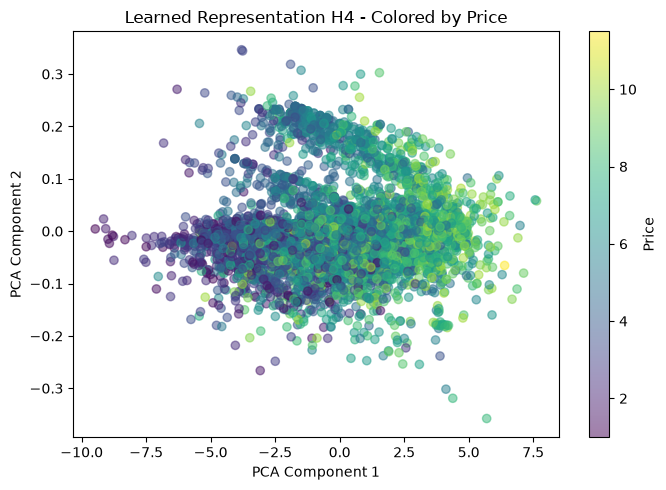

In [103]:

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

h4_2d = pca.fit_transform(
    h4_test
)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    h4_2d[:, 0],
    h4_2d[:, 1],
    c=y_test.to_numpy(),
    alpha=0.5
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "Learned Representation H4 - Colored by Price"
)

plt.colorbar(
    scatter,
    label="Price"
)

plt.tight_layout()
plt.show()



# 31. Scientific ML vs DL Comparison

Không được kết luận:

> DL tốt hơn chỉ vì một metric cao hơn.

Cần xem đồng thời:

| Criterion | Linear Regression | Random Forest | Gradient Boosting | 5-Layer MLP |
|---|---|---|---|---|
| Representation | Prepared | Prepared | Prepared | Learned |
| Nonlinearity | Low | High | High | High |
| Interpretability | High | Medium | Medium | Lower |
| Training cost | Low | Medium/High | Medium | Higher |
| Parameter learning | Coefficients | Trees | Boosted trees | Weights + biases |
| Optimization | Closed-form/solver | Tree construction | Sequential boosting | Backprop + Adam |

Các câu hỏi cần trả lời:

1. Model nào có RMSE thấp nhất?
2. Model nào có R² cao nhất?
3. MLP có cải thiện so với Gradient Boosting / Random Forest không?
4. Improvement có đủ lớn để bù training cost không?
5. Validation và test có ổn định không?
6. Training curves có cho thấy overfitting không?
7. Learned representation có tạo ra cấu trúc giá rõ hơn không?



# 32. Conclusion Template

Bạn có thể viết phần kết luận theo cấu trúc:

> Four models were evaluated for house-price prediction: Linear Regression, Random Forest Regressor, Gradient Boosting Regressor, and a five-layer MLP. All models used the same train/validation/test split and the same fitted preprocessing principle. Performance was evaluated using MAE, MSE, RMSE, R², and training time. The best predictive model was ______, achieving an RMSE of ______ and an R² of ______ on the held-out test set. The five-layer MLP learned multiple hidden representations before producing the final continuous price estimate. However, the DL model should only be considered preferable if its improvement in test performance is meaningful relative to its greater model complexity and training cost.

Điền các giá trị thực tế sau khi chạy notebook.



# 33. Save Artifacts

Lưu:

- fitted preprocessor;
- 3 ML models;
- DL `state_dict`;
- metadata;
- final comparison CSV.

PyTorch `state_dict()` lưu learned parameter state. Khi load lại cần dựng đúng architecture trước.


In [104]:

OUTPUT_DIR = Path(
    "house_price_assignment3_artifacts"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_preprocessor,
    OUTPUT_DIR / "preprocessor.joblib"
)

for name in [
    "Linear Regression",
    "Random Forest",
    "Gradient Boosting"
]:
    safe_name = (
        name.lower()
        .replace(" ", "_")
    )

    joblib.dump(
        final_models[name]["model"],
        OUTPUT_DIR / f"{safe_name}.joblib"
    )

torch.save(
    {
        "model_state_dict":
            final_dl_model.state_dict(),
        "input_dim":
            FINAL_INPUT_DIM,
        "architecture": [
            FINAL_INPUT_DIM,
            128,
            64,
            32,
            16,
            1
        ],
        "learning_rate":
            LEARNING_RATE,
        "epochs":
            best_epoch
    },
    OUTPUT_DIR / "house_price_5_layer_mlp.pth"
)

metadata = {
    "target": TARGET,
    "target_unit": "Billion VND",
    "raw_input_features":
        X.columns.tolist(),
    "processed_features":
        final_feature_names.tolist(),
    "best_dl_epoch":
        best_epoch,
    "dl_parameter_count":
        sum(
            p.numel()
            for p in final_dl_model.parameters()
            if p.requires_grad
        )
}

joblib.dump(
    metadata,
    OUTPUT_DIR / "metadata.joblib"
)

final_results_df.to_csv(
    OUTPUT_DIR /
    "house_price_model_comparison.csv",
    index=False
)

print("Saved artifacts:")
for path in OUTPUT_DIR.iterdir():
    print("-", path.name)


Saved artifacts:
- gradient_boosting.joblib
- house_price_5_layer_mlp.pth
- house_price_model_comparison.csv
- linear_regression.joblib
- metadata.joblib
- preprocessor.joblib
- random_forest.joblib



# 34. Final Checklist for Report

Chụp / đưa vào báo cáo các output sau:

1. Dataset shape + columns
2. Missing-value summary
3. Raw → Processed matrix shape
4. House Price Distribution
5. Area vs Price
6. Correlation Matrix
7. ML validation comparison
8. Công thức 5-layer forward propagation
9. Công thức MSE + Gradient Descent
10. 5-Layer MLP architecture + parameter count
11. Training vs Validation Loss
12. Training vs Validation RMSE
13. Final MAE/RMSE/R² comparison
14. Actual vs Predicted của model tốt nhất
15. Residual Distribution của model tốt nhất
16. Feature Importance
17. Learned Representation H4
18. Final scientific ML vs DL discussion
